<a href="https://colab.research.google.com/github/mario18acp-lang/Trabajos-escolares/blob/main/MDE_calculator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from datetime import date
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

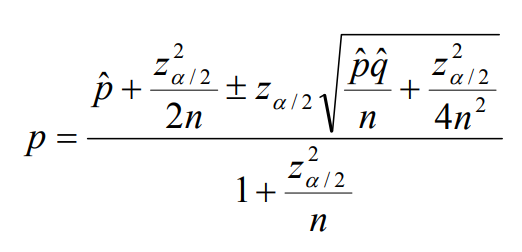

In [ ]:

def wilson_confidence_interval(n, p_hat, c):


    z_score = st.norm.ppf(1 - ((1 - c) / 2))
    correction_1 = z_score * z_score / (2*n)
    correction_2 = z_score * np.sqrt((p_hat*(1-p_hat) + z_score * z_score/(4 * n))/n) / (1 + z_score * z_score /n)
    additive_part = correction_1 + correction_2

    return (p_hat - additive_part, p_hat + additive_part)

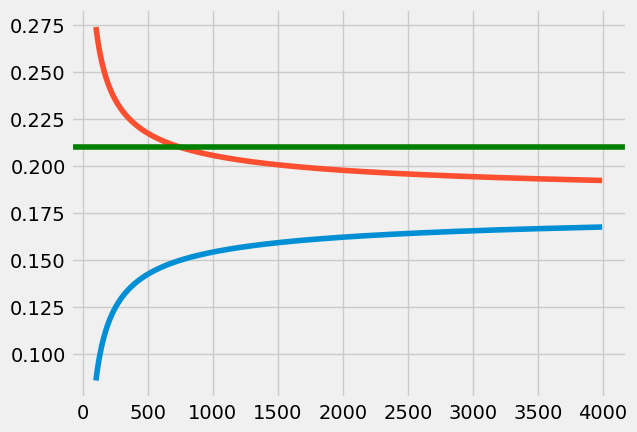

In [ ]:


# p means metric base line
p = .18
#N means estimated initial control group size
n = 10000
uplift = .03
cis = [wilson_confidence_interval(n,p, 0.95) for n in np.arange(.01, .4, 0.0005)*N]

plt.plot(np.arange(.01, .4, 0.0005)*N, np.array(cis)[:, 0])
plt.plot(np.arange(.01, .4, 0.0005)*N, np.array(cis)[:, 1])
plt.axhline(y=p+uplift, color='g', linestyle='-')

In [ ]:
df = pd.DataFrame(data=cis)
df["size %"] = (np.arange(.01, .4, 0.0005)*N)/N*100
df["min_uplift_captured"] = df[1]-p

In [ ]:
df[df["min_uplift_captured"]<uplift]

,0,1,size %,min_uplift_captured
131,0.150073,0.209927,7.55,0.029927
132,0.150180,0.209820,7.60,0.029820
133,0.150286,0.209714,7.65,0.029714
134,0.150390,0.209610,7.70,0.029610
135,0.150494,0.209506,7.75,0.029506
...,...,...,...,...
775,0.167575,0.192425,39.75,0.012425
776,0.167583,0.192417,39.80,0.012417
777,0.167592,0.192408,39.85,0.012408
778,0.167600,0.192400,39.90,0.012400
